In this notebook, we will try to estimate the parameters of the superposition of two Thomas processes, assuming that the number of offsprings is proportional to the variance $\sigma^2$.

**Imports**

In [1]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import contrast, f3
import json

First, we will generate and display a superposition of such two thomas processes.

In [2]:
with open('../../parameters/superposition-m-10.json', 'r') as file:
    params = json.load(file)

In [3]:
W = params['W']
w, h = W
mu = params['mu']
lam_p1, lam_p2 = params['thomas_1']['lam_p'], params['thomas_2']['lam_p']
sig1, sig2 = params['thomas_1']['sig'], params['thomas_2']['sig']
nu1, nu2 = mu*sig1**2, mu*sig2**2

In [4]:
thomas_process1 = ThomasProcess(lam_p1, nu1, sig1)
parents1, points_thomas1 = thomas_process1.generate(W, seed=46)
thomas_process2 = ThomasProcess(lam_p2, nu2, sig2)
parents2, points_thomas2 = thomas_process2.generate(W, seed=46)
points_sup = np.concatenate([points_thomas1, points_thomas2])

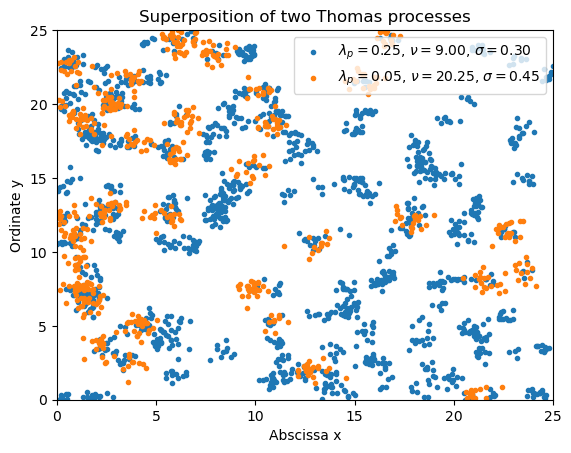

In [5]:
display_superposition([points_thomas1, points_thomas2], 
                      window=W, 
                      title="Superposition of two Thomas processes", 
                      labels=[fr'$\lambda_p = {lam_p1: .2f}$, $\nu = {nu1: .2f}$, $\sigma = {sig1: .2f}$', 
                              fr'$\lambda_p = {lam_p2: .2f}$, $\nu = {nu2: .2f}$, $\sigma = {sig2: .2f}$'])

In [6]:
threshold = 0.2
r_values = np.linspace(threshold, w/5, 500)
I_values = periodogram_bessel(points_sup, W, r_values)

In [7]:
lam_hat = intensity(points_sup, W)

In [8]:
def contrast_aux(theta):  # theta = [mu, lam_p1, sig1, sig2]
    f_theo = f3(r_values, lam_hat, theta)
    dr = r_values[1] - r_values[0]
    return contrast(I_values, f_theo, dr)

In [9]:
theta0 = [1, 1, 1, 1]  # Initial guess

bounds = [(1e-6, None)]*4  # Positivity constraints

result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)

print('Real parameters:\n------------------')
real_params = [mu, lam_p1, sig1, sig2]
print(real_params)
print('\nEstimated parameters:\n------------------')
print([f'{param: .2f}' for param in result.x])
print('\nRelative error:\n------------------')
print([f'{100*abs(estim - real)/real: .2f}' + '%' for real, estim in zip(result.x, real_params)])
print('\nReport:\n------------------')
print(result)

Real parameters:
------------------
[100, 0.25, 0.3, 0.45]

Estimated parameters:
------------------
[' 130.25', ' 1.00', ' 0.00', ' 0.36']

Relative error:
------------------
[' 23.22%', ' 75.00%', ' 29998240.80%', ' 24.93%']

Report:
------------------
  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 10.30788990689728
        x: [ 1.302e+02  1.000e+00  1.000e-06  3.602e-01]
      nit: 15
      jac: [ 5.329e-07  0.000e+00  0.000e+00  7.105e-07]
     nfev: 125
     njev: 25
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


In [10]:
contrast_aux(real_params)

36.6364233293473

- The estimator is not good enough + Identifiability problem

**Using the PCF instead of the periodogram**

In [6]:
r_values, g_values = g(points_sup, W)  # Estimating the p.c.f

R[write to console]: Loading required package: spatstat.data

R[write to console]: Loading required package: spatstat.univar

R[write to console]: spatstat.univar 3.1-2

R[write to console]: Loading required package: spatstat.geom

R[write to console]: spatstat.geom 3.3-6

R[write to console]: Loading required package: spatstat.random

R[write to console]: spatstat.random 3.3-3

R[write to console]: Loading required package: spatstat.explore

R[write to console]: Loading required package: nlme

R[write to console]: spatstat.explore 3.4-2

R[write to console]: Loading required package: spatstat.model

R[write to console]: Loading required package: rpart

R[write to console]: spatstat.model 3.3-5

R[write to console]: Loading required package: spatstat.linnet

R[write to console]: spatstat.linnet 3.2-5

R[write to console]: 
spatstat 3.3-2 
For an introduction to spatstat, type ‘beginner’ 


R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1

In [7]:
threshold = 10  # For radii smaller than the bandwidth, the estimator explodes
r_values = r_values[threshold:]
g_values = g_values[threshold:]

In [10]:
lam_hat = intensity(points_sup, W)

In [11]:
def contrast_aux(theta):  # Auxiliary contrast function that takes theta as a parameter
    g_theo_list = g_theo_2thomas(r_values, lam_hat, theta)
    dr = r_values[1] - r_values[0]
    return contrast(g_values, g_theo_list, dr)

In [14]:
theta0 = [100, 1, 1, 1]  # Initial guess

bounds = [(1e-6, None)]*4  # Positivity constraints

result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)

print('Real parameters:\n------------------')
real_params = [mu, lam_p1, sig1, sig2]
print(real_params)
print('\nEstimated parameters:\n------------------')
print([f'{param: .2f}' for param in result.x])
print('\nRelative error:\n------------------')
print([f'{100*abs(estim - real)/real: .2f}' + '%' for real, estim in zip(result.x, real_params)])
print('\nReport:\n------------------')
print(result)

Real parameters:
------------------
[100, 0.25, 0.3, 0.45]

Estimated parameters:
------------------
[' 135.33', ' 0.20', ' 0.35', ' 3.59']

Relative error:
------------------
[' 26.11%', ' 26.90%', ' 14.81%', ' 87.48%']

Report:
------------------
  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.0058789229575036805
        x: [ 1.353e+02  1.970e-01  3.522e-01  3.593e+00]
      nit: 47
      jac: [ 9.888e-09  6.357e-06  7.882e-06  8.674e-10]
     nfev: 390
     njev: 78
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


In [16]:
contrast_aux(real_params)

0.32443993893011164

Same problem :(